# Data Generation for Dynamical Systems: Repressilator, Duffing Oscillator, and IRMA Model

This notebook provides a comprehensive explanation of how data is generated for three key dynamical systems in the BioKoopman project:

1. **Repressilator** - A synthetic gene regulatory network that exhibits oscillatory behavior
2. **Duffing Oscillator** - A nonlinear mechanical oscillator with complex dynamics
3. **IRMA Model** - An *In vivo* Reverse-engineering and Modeling Assessment synthetic gene regulatory network

Each system demonstrates different types of dynamical behavior and serves as a benchmark for testing Koopman operator methods.

## Table of Contents
1. [Overview of Data Generation Pipeline](#overview)
2. [Repressilator Model](#repressilator)
3. [Duffing Oscillator](#duffing)
4. [IRMA Model](#irma)
5. [Data Format and Storage](#data-format)
6. [Example Data Generation](#examples)

## Overview of Data Generation Pipeline {#overview}

The data generation pipeline in this project follows a consistent pattern across all dynamical systems:

1. **System Definition**: Each dynamical system is defined as a class with methods for:
   - Right-hand side (RHS) of the ODE system
   - Parameter suggestions
   - Time array suggestions
   - Simulation execution

2. **Parameter Generation**: Random parameter combinations are generated within physically meaningful ranges

3. **Initial Condition Generation**: Random initial conditions are sampled from appropriate ranges

4. **Time Series Simulation**: ODEs are integrated using `scipy.integrate.odeint`

5. **Data Storage**: Results are stored as pandas DataFrames and saved as pickle files

Let's examine each system in detail.

## 1. Repressilator Model {#repressilator}

The Repressilator is a synthetic gene regulatory network where three proteins suppress each other in a circular pattern, creating oscillatory behavior.

### Mathematical Model

The system consists of 6 state variables: 3 mRNA concentrations ($m_i$) and 3 protein concentrations ($p_i$):

$$\dot{m_0} = \alpha_0 + \frac{\alpha}{1 + (p_2/K)^n} - \delta_m \cdot m_0$$
$$\dot{m_1} = \alpha_0 + \frac{\alpha}{1 + (p_0/K)^n} - \delta_m \cdot m_1$$
$$\dot{m_2} = \alpha_0 + \frac{\alpha}{1 + (p_1/K)^n} - \delta_m \cdot m_2$$
$$\dot{p_0} = \beta \cdot m_0 - \delta_p \cdot p_0$$
$$\dot{p_1} = \beta \cdot m_1 - \delta_p \cdot p_1$$
$$\dot{p_2} = \beta \cdot m_2 - \delta_p \cdot p_2$$

where the state variables are:
- $y_0 = m_0$, $y_1 = m_1$, $y_2 = m_2$ (mRNA concentrations)
- $y_3 = p_0$, $y_4 = p_1$, $y_5 = p_2$ (protein concentrations)

### Parameters
- `α₀` (alpha0): Basal transcription rate
- `α` (alpha): Maximum transcription rate
- `K`: Half-saturation constant for repression
- `n`: Hill coefficient (cooperativity)
- `δₘ` (delta_m): mRNA degradation rate
- `δₚ` (delta_p): Protein degradation rate
- `β` (beta): Translation rate

### Parameter 

**Complete parameter vector:** [α₀, α, K, n, δₘ, δₚ, β]  
**Suggested parameters:** [0, 1, 40, 2, 0.3466, 0.1933, 10]

### Initial Conditions
- Default: [0, 0, 0, 2, 1, 3] (fixed)
- Random sampling: Uniform distribution [0, 100] for all 6 variables

### Time Domain
- Suggested time span: [0, 1200] with 1000 points
- This captures multiple oscillation cycles

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sys
import os

# Add utils to path
sys.path.append('../utils')
from data_loader import RepressilatorModel, generate_data_repr, isolated_repressilator_fn

In [2]:
# Demonstration of Repressilator data generation
print("=== REPRESSILATOR MODEL DEMONSTRATION ===")
print("\n1. Model Initialization")
print("  - Sample Initial Conditions")
y0 = np.random.uniform(0, 100, size=6).tolist()  # Random initial conditions for mRNA and protein
repr_model = RepressilatorModel(y0)
print(f"   - Number of state variables: {repr_model.n_outputs()}")
print(f"   - Number of parameters: {repr_model.n_parameters()} (Note: actual implementation uses 7 parameters)")
print(f"   - initial conditions: {repr_model._y0}")

print("\n2. Parameters and Time Domain")
suggested_params = [0.03, 10, 40, 2, 0.3466, 0.0693, 10]
suggested_times = np.linspace(0, 250, 200)
print(f"   - Suggested parameters [α₀, α, K, n, δₘ, δₚ, β]: {suggested_params}")
print(f"   - Parameter meanings: basal_rate={suggested_params[0]}, max_rate={suggested_params[1]}, K={suggested_params[2]}, hill_coef={suggested_params[3]}, mRNA_deg={suggested_params[4]}, protein_deg={suggested_params[5]}, translation={suggested_params[6]}")
print(f"   - Time domain: [{suggested_times[0]:.1f}, {suggested_times[-1]:.1f}] with {len(suggested_times)} points")

print("\n3. Simulation Example")
solution = repr_model.simulate(suggested_params, suggested_times)
print(f"   - Solution shape: {solution.shape} (time_points x state_variables)")
print(f"   - State variables: [m₀, m₁, m₂, p₀, p₁, p₂]")

=== REPRESSILATOR MODEL DEMONSTRATION ===

1. Model Initialization
  - Sample Initial Conditions
   - Number of state variables: 6
   - Number of parameters: 7 (Note: actual implementation uses 7 parameters)
   - initial conditions: [ 5.71755958 84.67903327 15.94774531 38.1148515  96.00949491 22.61916641]

2. Parameters and Time Domain
   - Suggested parameters [α₀, α, K, n, δₘ, δₚ, β]: [0.03, 10, 40, 2, 0.3466, 0.0693, 10]
   - Parameter meanings: basal_rate=0.03, max_rate=10, K=40, hill_coef=2, mRNA_deg=0.3466, protein_deg=0.0693, translation=10
   - Time domain: [0.0, 250.0] with 200 points

3. Simulation Example
   - Solution shape: (200, 6) (time_points x state_variables)
   - State variables: [m₀, m₁, m₂, p₀, p₁, p₂]


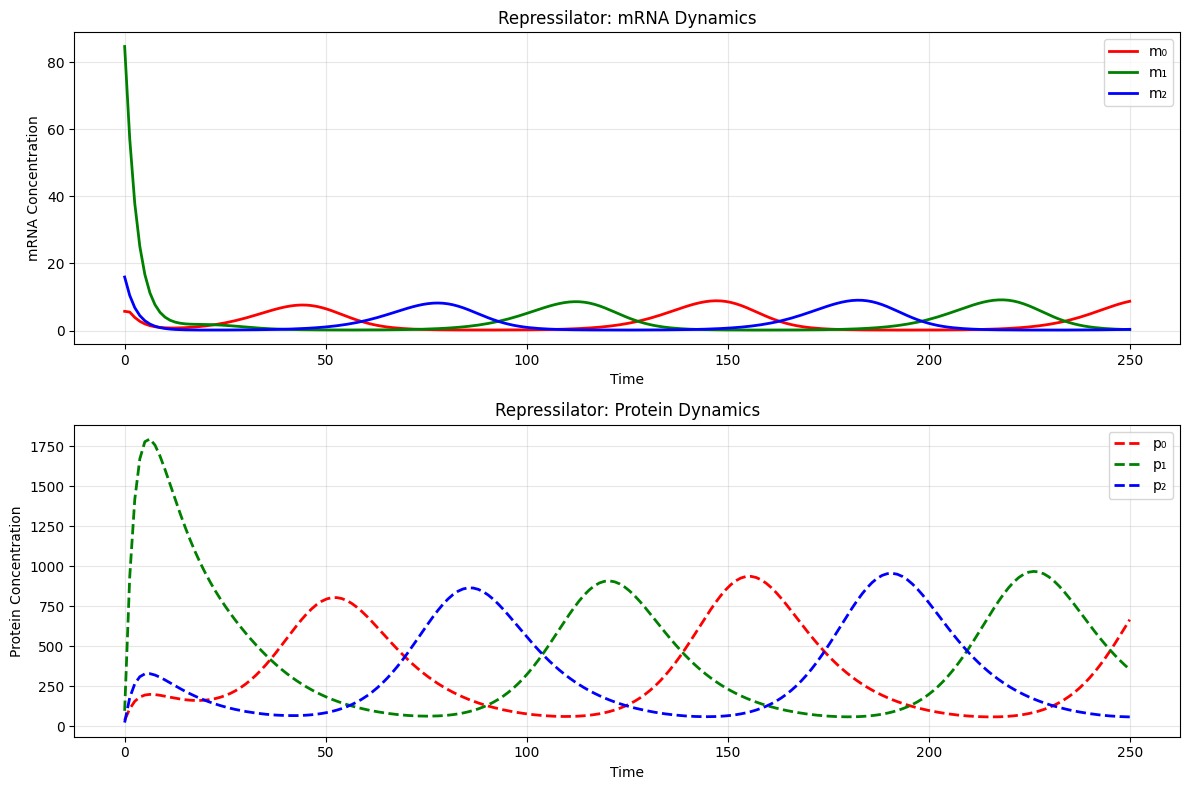

The Repressilator exhibits clear oscillatory behavior with:
- Phase-shifted oscillations between the three genes
- Proteins lagging behind their corresponding mRNAs


In [3]:
# Visualize Repressilator dynamics
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot mRNA concentrations
axes[0].plot(suggested_times, solution[:, 0], 'r-', label='m₀', linewidth=2)
axes[0].plot(suggested_times, solution[:, 1], 'g-', label='m₁', linewidth=2)
axes[0].plot(suggested_times, solution[:, 2], 'b-', label='m₂', linewidth=2)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('mRNA Concentration')
axes[0].set_title('Repressilator: mRNA Dynamics')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot protein concentrations
axes[1].plot(suggested_times, solution[:, 3], 'r--', label='p₀', linewidth=2)
axes[1].plot(suggested_times, solution[:, 4], 'g--', label='p₁', linewidth=2)
axes[1].plot(suggested_times, solution[:, 5], 'b--', label='p₂', linewidth=2)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Protein Concentration')
axes[1].set_title('Repressilator: Protein Dynamics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The Repressilator exhibits clear oscillatory behavior with:")
print("- Phase-shifted oscillations between the three genes")
print("- Proteins lagging behind their corresponding mRNAs")

## 2. Duffing Oscillator {#duffing}

The Duffing oscillator is a nonlinear mechanical system that can exhibit chaotic behavior. It's described by a second-order differential equation with both linear and nonlinear restoring forces.

### Mathematical Model

The Duffing equation is:
$$\frac{d^2 x}{dt^2} + \delta \frac{dx}{dt} + \beta x^3 + \alpha x = \gamma \cos(\omega t)$$

Converting to first-order system:
$$\dot{y_0} = y_1$$
$$\dot{y_1} = -\delta y_1 - \beta y_0^3 - \alpha y_0 + \gamma \cos(\omega t)$$

### Parameters
- `δ` (delta): Damping coefficient
- `β` (beta): Nonlinear restoring force coefficient  
- `α` (alpha): Linear restoring force coefficient
- `γ` (gamma): Driving force amplitude
- `ω` (omega): Driving force frequency

### Parameter Ranges
- `δ`: [0, 1]    # Damping
- `β`: [0, 2]    # Nonlinear term
- `α`: [-2, 2]   # Linear term (can be negative for hard spring)
- `γ`: [0, 1]    # Driving amplitude
- `ω`: [0, 2]    # Driving frequency

### Initial Conditions
- Default: [0, 0] (position, velocity)
- Random sampling: Uniform distribution [-2, 2] for both variables

### Time Domain
- Suggested time span: [0, 50] with 1000 points
- Captures transient and steady-state behavior

In [37]:
# Import Duffing oscillator components
from data_loader import ForcedDuffingOscillator, generate_data_dfn, duffing_oscillator_fn

print("=== DUFFING OSCILLATOR (NONLINEAR CASE) MODEL DEMONSTRATION ===")
print("Showcasing different behaviors by varying initial conditions for the equation ẍ = -x + x³.")

print("\n1. Model Initialization")
duffing_model = ForcedDuffingOscillator()
print(f"   - Number of state variables: {duffing_model.n_outputs()}")
print(f"   - State variables: [position, velocity]")

# Time domain for demonstration
suggested_times = np.linspace(0, 20, 400) 
print(f"   - Time domain: [{suggested_times[0]:.1f}, {suggested_times[-1]:.1f}] with {len(suggested_times)} points")

print("\n2. Parameters and Simulation for Different Behaviors")
# Parameters for the undamped, unforced nonlinear oscillator
params = [0.0, 1.0, -1.0, 0.0, 0.0]  # δ, β, α, γ, ω
print(f"   - Using parameters [δ, β, α, γ, ω]: {params}")

# Define initial conditions to showcase different behaviors
# The system has fixed points at (0,0), (1,0), and (-1,0)
initial_conditions = {
    "Orbit around right well": [1.1, 0.1],
    "Orbit around left well": [-1.1, -0.1],
    "Orbit around both wells": [-0.5, 0.5]
}

solutions = {}
for name, ic in initial_conditions.items():
    duffing_model._y0 = ic
    solution = duffing_model.simulate(params, suggested_times)
    solutions[name] = solution
    print(f"   - Simulated '{name}' from IC ({ic[0]:.2f}, {ic[1]:.2f}). Solution shape: {solution.shape}")

=== DUFFING OSCILLATOR (NONLINEAR CASE) MODEL DEMONSTRATION ===
Showcasing different behaviors by varying initial conditions for the equation ẍ = -x + x³.

1. Model Initialization
   - Number of state variables: 2
   - State variables: [position, velocity]
   - Time domain: [0.0, 20.0] with 400 points

2. Parameters and Simulation for Different Behaviors
   - Using parameters [δ, β, α, γ, ω]: [0.0, 1.0, -1.0, 0.0, 0.0]
   - Simulated 'Orbit around right well' from IC (1.10, 0.10). Solution shape: (400, 2)
   - Simulated 'Orbit around left well' from IC (-1.10, -0.10). Solution shape: (400, 2)
   - Simulated 'Orbit around both wells' from IC (-0.50, 0.50). Solution shape: (400, 2)


=== DUFFING OSCILLATOR PHASE PORTRAITS (NONLINEAR CASE) ===
Plotting phase portraits for different initial conditions.


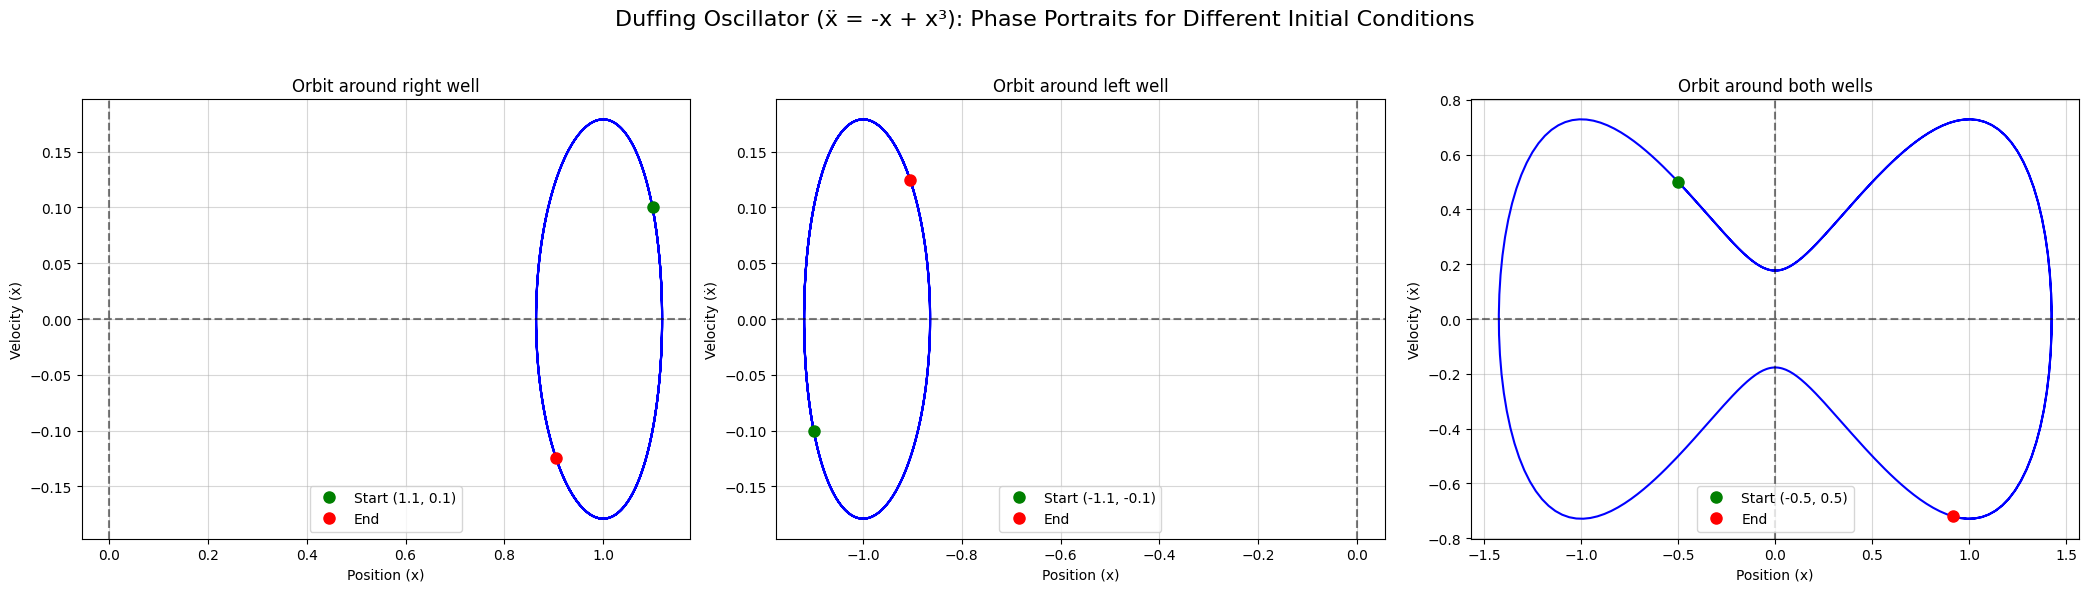


Each plot shows a different behavior of the undamped, unforced Duffing oscillator based on the starting point:
- The system has two stable wells (potential minima).
- Depending on the initial energy, the trajectory can orbit within one well or have enough energy to orbit both.


In [38]:
# Visualize different Duffing oscillator dynamics
print("=== DUFFING OSCILLATOR PHASE PORTRAITS (NONLINEAR CASE) ===")
print("Plotting phase portraits for different initial conditions.")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Duffing Oscillator (ẍ = -x + x³): Phase Portraits for Different Initial Conditions', fontsize=16)

for i, (name, solution) in enumerate(solutions.items()):
    ax = axes[i]
    ic = initial_conditions[name]
    
    # Plot phase portrait: position (x-axis) vs. velocity (y-axis)
    ax.plot(solution[:, 0], solution[:, 1], 'b-', linewidth=1.5)
    
    # Mark the start and end points
    ax.plot(solution[0, 0], solution[0, 1], 'go', markersize=8, label=f'Start ({ic[0]:.1f}, {ic[1]:.1f})')
    ax.plot(solution[-1, 0], solution[-1, 1], 'ro', markersize=8, label='End')
    
    ax.set_title(name)
    ax.set_xlabel('Position (x)')
    ax.set_ylabel('Velocity (ẋ)')
    ax.legend()
    ax.grid(True, alpha=0.5)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax.axvline(0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nEach plot shows a different behavior of the undamped, unforced Duffing oscillator based on the starting point:")
print("- The system has two stable wells (potential minima).")
print("- Depending on the initial energy, the trajectory can orbit within one well or have enough energy to orbit both.")

## 3. IRMA Model {#irma}

The IRMA model is a synthetic gene regulatory network consisting of five interacting genes: CBF1, GAL4, SWI5, GAL80, and ASH1.

### Mathematical Model

The system consists of 5 state variables representing gene expression levels:

$$\frac{dx_1}{dt} = \alpha_1 + v_1 \frac{k_1^{h_1}}{k_1^{h_1} + x_5^{h_1}} - d_1 x_1$$

$$\frac{dx_2}{dt} = \alpha_2 + v_2 \frac{x_1^{h_2}}{k_2^{h_2} + x_1^{h_2}} - d_2 x_2$$

$$\frac{dx_3}{dt} = \alpha_3 + v_3 \frac{x_2^{h_3}}{k_3^{h_3} + x_2^{h_3} \left(1 + \frac{x_4^{h_6}}{\gamma^{h_6}}\right)} - d_3 x_3$$

$$\frac{dx_4}{dt} = \alpha_4 + v_4 \frac{x_3^{h_4}}{k_4^{h_4} + x_3^{h_4}} - d_4 x_4$$

$$\frac{dx_5}{dt} = \alpha_5 + v_5 \frac{x_3^{h_5}}{k_5^{h_5} + x_3^{h_5}} - d_5 x_5$$

where $x_1, x_2, x_3, x_4, x_5$ represent CBF1, GAL4, SWI5, GAL80, and ASH1 respectively.

### Parameters
- `α` (alpha): Basal expression rates (5 values)
- `v`: Maximum expression rates (5 values)
- `k`: Half-saturation constants (5 values)
- `h`: Hill coefficients (6 values, mostly fixed)
- `d`: Degradation rates (5 values)
- `γ` (gamma): Inhibition constant


### Initial Conditions
- Random sampling: Uniform distribution [0, 1] for all 5 variables

### Time Domain
- Suggested time span: [0, 1500] with 1500 points
- Captures long-term regulatory dynamics

In [43]:
# Import IRMA model components
from data_loader import IRMASystem, generate_data_irma, irma_fn

print("=== IRMA MODEL DEMONSTRATION ===")
print("\n1. Model Initialization")
irma_model = IRMASystem()
print(f"   - Number of state variables: {irma_model.n_outputs()}")
print(f"   - Number of parameters: {irma_model.n_parameters()}")
print(f"   - Default initial conditions: {irma_model._y0}")

print("\n2. Suggested Parameters and Time Domain")
suggested_params = irma_model.suggested_parameters()
suggested_times = np.linspace(0, 800, 400)
print(f"   - Suggested parameters:")
for key, value in suggested_params.items():
    if isinstance(value, list):
        print(f"     {key}: {[f'{v:.4f}' if isinstance(v, float) else v for v in value]}")
    else:
        print(f"     {key}: {value}")
print(f"   - Time domain: [{suggested_times[0]:.1f}, {suggested_times[-1]:.1f}] with {len(suggested_times)} points")

print("\n3. Simulation Example")
solution = irma_model.simulate(suggested_params, suggested_times)
print(f"   - Solution shape: {solution.shape} (time_points x state_variables)")
print(f"   - State variables: [CBF1, GAL4, SWI5, GAL80, ASH1]")

=== IRMA MODEL DEMONSTRATION ===

1. Model Initialization
   - Number of state variables: 5
   - Number of parameters: 6
   - Default initial conditions: [0.83244264 0.21233911 0.18182497 0.18340451 0.30424224]

2. Suggested Parameters and Time Domain
   - Suggested parameters:
     alpha: [0, '0.0001', '0.0030', '0.0007', '0.0006']
     v: ['0.0400', '0.0260', '0.0200', '0.0140', '0.0180']
     k: ['0.0003', '0.0370', '0.0100', '1.8840', '0.0477']
     h: [1, 4, 4, 1, 4, 4]
     d: ['0.0220', '0.0470', '0.4210', '0.0980', '0.0500']
     gamma: 0.6
   - Time domain: [0.0, 800.0] with 400 points

3. Simulation Example
   - Solution shape: (400, 5) (time_points x state_variables)
   - State variables: [CBF1, GAL4, SWI5, GAL80, ASH1]


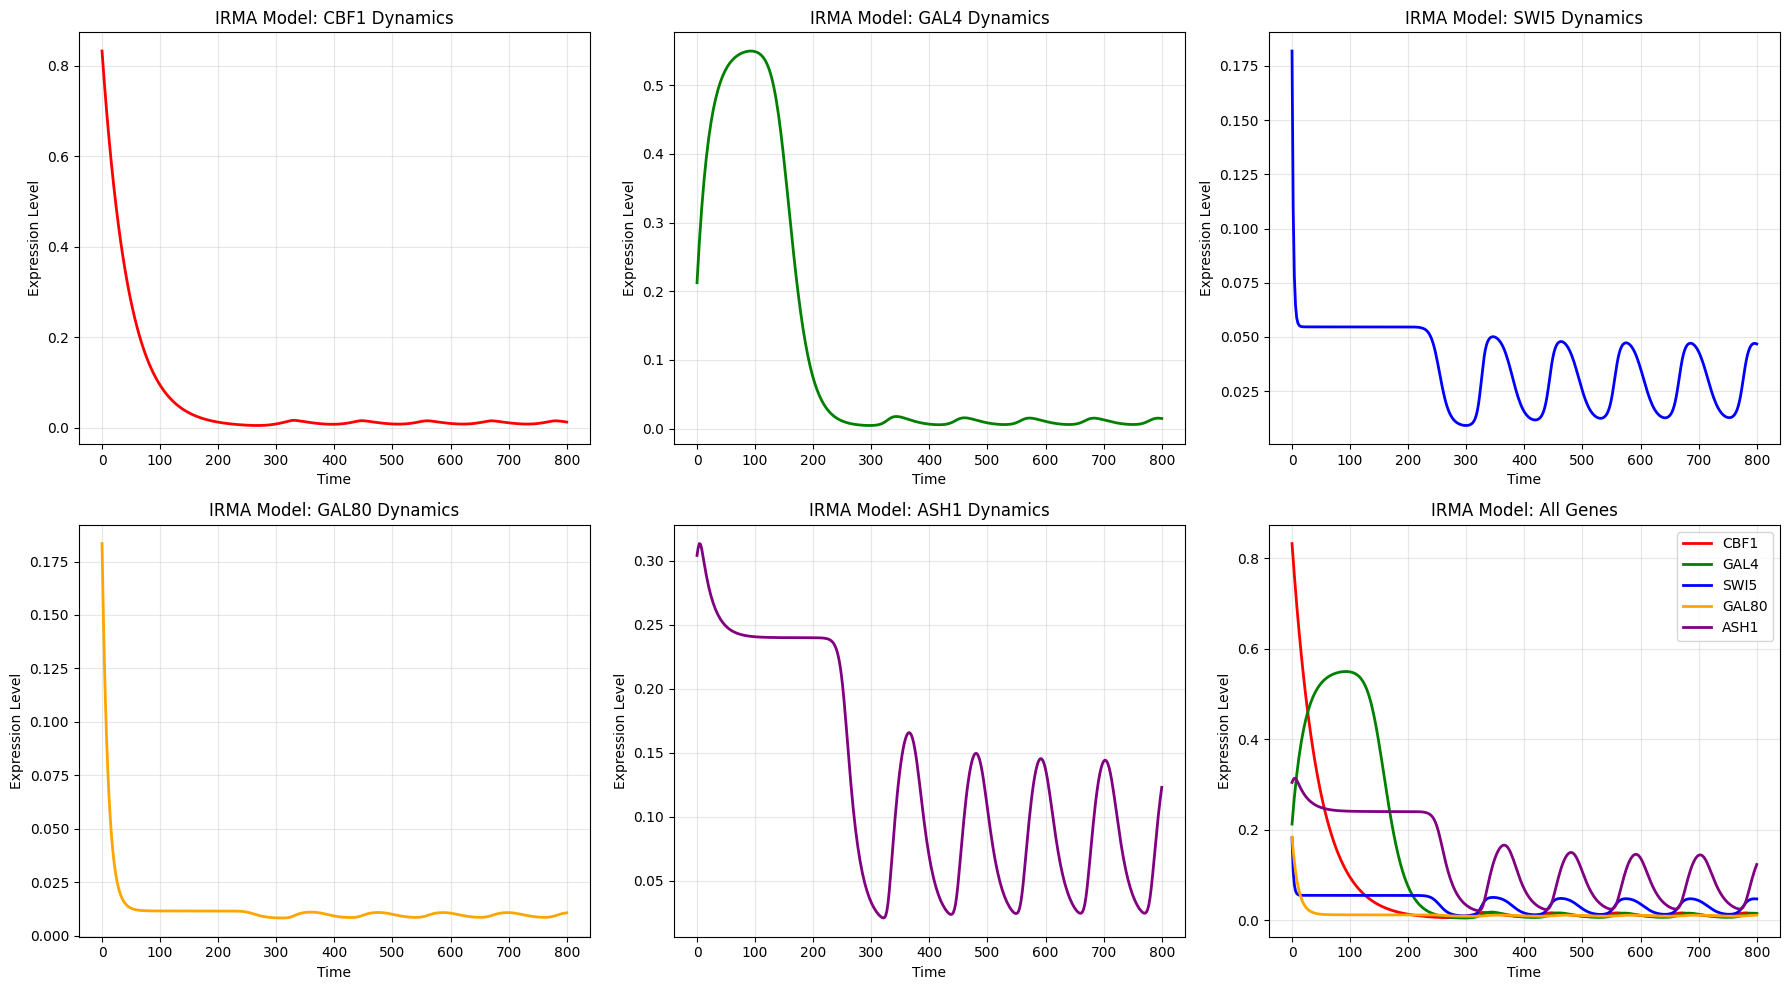

The IRMA model demonstrates:
- Complex regulatory interactions between 5 genes
- Both activation and repression mechanisms
- Long-term convergence to steady states or limit cycles
- Realistic gene regulatory network behavior


In [44]:
# Visualize IRMA model dynamics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

gene_names = ['CBF1', 'GAL4', 'SWI5', 'GAL80', 'ASH1']
colors = ['red', 'green', 'blue', 'orange', 'purple']

# Plot individual gene dynamics
for i in range(5):
    axes[i].plot(suggested_times, solution[:, i], color=colors[i], linewidth=2)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Expression Level')
    axes[i].set_title(f'IRMA Model: {gene_names[i]} Dynamics')
    axes[i].grid(True, alpha=0.3)

# Plot all genes together
for i in range(5):
    axes[5].plot(suggested_times, solution[:, i], color=colors[i], linewidth=2, label=gene_names[i])
axes[5].set_xlabel('Time')
axes[5].set_ylabel('Expression Level')
axes[5].set_title('IRMA Model: All Genes')
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The IRMA model demonstrates:")
print("- Complex regulatory interactions between 5 genes")
print("- Both activation and repression mechanisms")
print("- Long-term convergence to steady states or limit cycles")
print("- Realistic gene regulatory network behavior")

## Data Format and Storage {#data-format}

All generated datasets follow a consistent format:

### File Naming Convention
```
{system_name}_{n_param_sets}_{n_trajectories}_{time_points}_{time_interval}_param_{parameters}.pkl
```

### Data Structure
- **Format**: Pandas DataFrame saved as pickle files
- **Index**: Trajectory identifier (repeated for each time point in a trajectory)
- **Columns**: State variables at each time point
- **Shape**: `(total_time_points, n_state_variables)`

### Example File Names
- `isolated_repressilator_1_15000_201_250_param_[...].pkl`
- `duffing_oscillator_1_6000_201_10_param_[...].pkl`
- `irma_1_3000_401_800.pkl`

### Data Organization
Each trajectory is identified by an index, making it easy to:
- Extract individual trajectories
- Batch process multiple trajectories
- Maintain parameter-trajectory correspondence

In [47]:
# Demonstrate data generation and storage
print("=== DATA GENERATION AND STORAGE DEMONSTRATION ===")

# Generate small datasets for each system
print("\n1. Generating sample datasets...")

# Parameters for small demo datasets
n_param_sets = 1      # Number of parameter combinations
num_samples = 3       # Number of initial conditions per parameter set
time_points = 50      # Reduced for demo
time_intervals = 20   # Shorter time span for demo
demo_path = '../data_demo/'  # Demo data directory

# Create demo directory
os.makedirs(demo_path, exist_ok=True)

# 1. Generate Repressilator data
print("   - Generating Repressilator data...")
repr_params = [1,1000,1,2,1,5,5]  # Example parameters
repr_data = isolated_repressilator_fn(n_param_sets, num_samples, time_points, 
                                     time_intervals, repr_params, demo_path)
print(f"     Generated data shape: {repr_data.shape}")
print(f"     Number of unique trajectories: {len(repr_data.index.unique())}")

# 2. Generate Duffing data
print("   - Generating Duffing data...")
duffing_params = [0.2, 1.0, -1.0, 0.3, 1.2]  # Example parameters
duffing_data = duffing_oscillator_fn(n_param_sets, num_samples, time_points, 
                                    time_intervals, duffing_params, demo_path)
print(f"     Generated data shape: {duffing_data.shape}")
print(f"     Number of unique trajectories: {len(duffing_data.index.unique())}")

# 3. Generate IRMA data
print("   - Generating IRMA data...")
irma_params = None  # Use random parameters
irma_data = irma_fn(n_param_sets, num_samples, time_points, 
                   time_intervals, irma_params, demo_path)
print(f"     Generated data shape: {irma_data.shape}")
print(f"     Number of unique trajectories: {len(irma_data.index.unique())}")

print("\n2. Data Structure Analysis")
print(f"   Total trajectories per system: {n_param_sets * num_samples}")
print(f"   Time points per trajectory: {time_points}")
print(f"   Expected total data points per system: {n_param_sets * num_samples * time_points}")

=== DATA GENERATION AND STORAGE DEMONSTRATION ===

1. Generating sample datasets...
   - Generating Repressilator data...
     Generated data shape: (150, 6)
     Number of unique trajectories: 3
   - Generating Duffing data...
     Generated data shape: (150, 2)
     Number of unique trajectories: 3
   - Generating IRMA data...
     Generated data shape: (150, 5)
     Number of unique trajectories: 3

2. Data Structure Analysis
   Total trajectories per system: 3
   Time points per trajectory: 50
   Expected total data points per system: 150


=== DETAILED DATA STRUCTURE ANALYSIS ===

1. Repressilator Data Structure:
   - DataFrame shape: (150, 6)
   - Column names: [0, 1, 2, 3, 4, 5]
   - Index (trajectory IDs): [0, 1, 2]
   - Data types: [dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64')]

   Sample trajectory (ID=0):
   - Shape: (50, 6)
   - First 5 rows:
           0          1          2          3          4          5
0  86.310343  62.329813  33.089802   6.355835  31.098232  32.518332
0  58.094039  42.124781  22.508897  58.952422  46.221778  26.664859
0  39.651245  28.460992  15.512754  47.083214  34.441183  18.833968
0  28.100911  19.478401  11.075494  33.596315  23.827814  13.252164
0  21.701797  13.706540   8.589507  24.841049  16.554571   9.812052

2. Duffing Data Structure:
   - DataFrame shape: (150, 2)
   - Column names: [0, 1]
   - Number of trajectories: 3

3. IRMA Data Structure:
   - DataFrame shape: (150, 5)
   - Column names: [0, 1, 2, 3, 4]
   - Nu

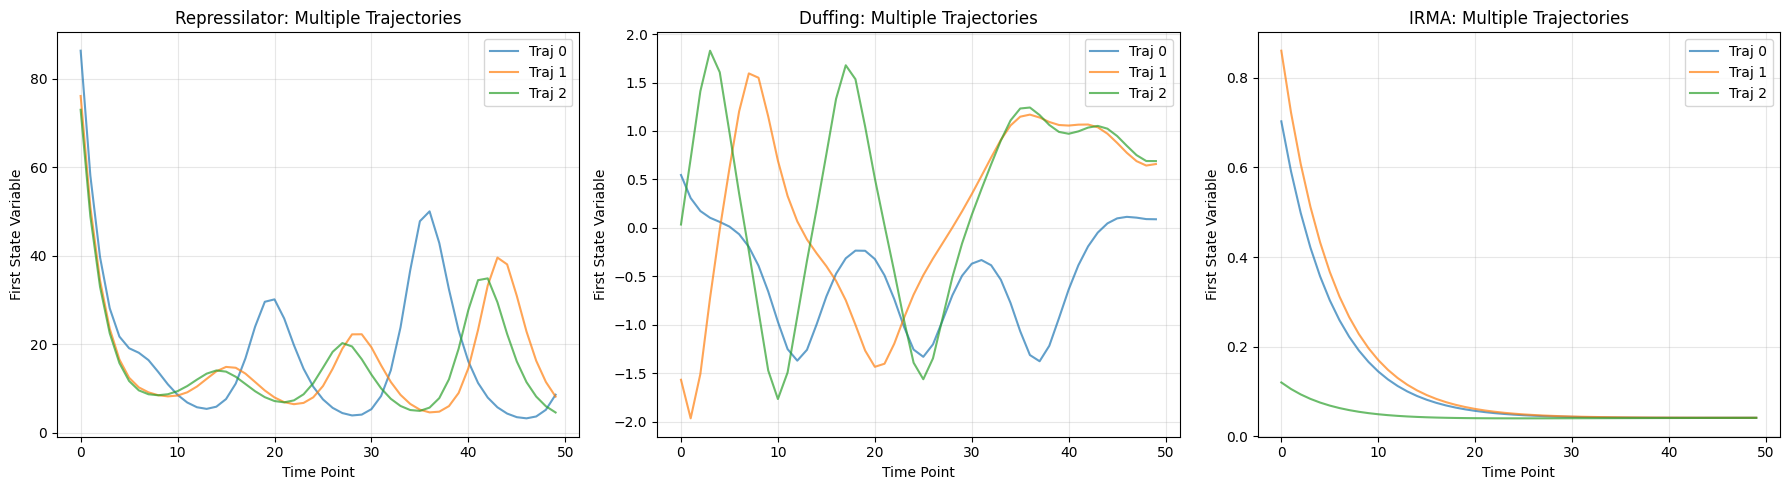

In [48]:
# Examine data structure in detail
print("=== DETAILED DATA STRUCTURE ANALYSIS ===")

# Examine Repressilator data structure
print("\n1. Repressilator Data Structure:")
print(f"   - DataFrame shape: {repr_data.shape}")
print(f"   - Column names: {list(repr_data.columns)}")
print(f"   - Index (trajectory IDs): {sorted(repr_data.index.unique())}")
print(f"   - Data types: {repr_data.dtypes.tolist()}")

# Show sample data for first trajectory
first_traj = repr_data[repr_data.index == 0]
print(f"\n   Sample trajectory (ID=0):")
print(f"   - Shape: {first_traj.shape}")
print(f"   - First 5 rows:")
print(first_traj.head().to_string())

# Similar analysis for other systems
print("\n2. Duffing Data Structure:")
print(f"   - DataFrame shape: {duffing_data.shape}")
print(f"   - Column names: {list(duffing_data.columns)}")
print(f"   - Number of trajectories: {len(duffing_data.index.unique())}")

print("\n3. IRMA Data Structure:")
print(f"   - DataFrame shape: {irma_data.shape}")
print(f"   - Column names: {list(irma_data.columns)}")
print(f"   - Number of trajectories: {len(irma_data.index.unique())}")

# Visualize data organization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot trajectories for each system
systems = [('Repressilator', repr_data, 6), ('Duffing', duffing_data, 2), ('IRMA', irma_data, 5)]
for i, (name, data, n_vars) in enumerate(systems):
    # Plot first few trajectories
    for traj_id in data.index.unique()[:3]:  # First 3 trajectories
        traj_data = data[data.index == traj_id]
        # Plot first state variable
        axes[i].plot(range(len(traj_data)), traj_data.iloc[:, 0], 
                    alpha=0.7, linewidth=1.5, label=f'Traj {traj_id}')
    
    axes[i].set_xlabel('Time Point')
    axes[i].set_ylabel('First State Variable')
    axes[i].set_title(f'{name}: Multiple Trajectories')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Example Data Generation {#examples}

Here we demonstrate how to generate larger datasets similar to those used in the actual experiments.

In [49]:
# Example: Using KoopmanDataHandler for Data Generation and Trajectory Segmentation
print("=== DATA GENERATION WITH KoopmanDataHandler ===")
print("\nThe KoopmanDataHandler provides a complete pipeline for:")
print("1. Loading/generating data from various dynamical systems")
print("2. Preprocessing and normalization")
print("3. Trajectory segmentation for training")
print("4. Creating PyTorch DataLoaders")

# Import the data handler
import sys
sys.path.append('../')
from data_handler import KoopmanDataHandler

# Example 1: IRMA Model Configuration
print("\n=== Example 1: IRMA Model ===")

irma_config = {
    "dataset": "IRMA",
    "data_dir": "../data",
    "train_size": 0.8,
    "val_size": 0.1,
    "batch_size": 32,
    "noise": 0.0,
    "orthogonal_projection": False,
    "num_combinations": 1,        # Number of parameter combinations
    "num_samples": 100,           # Number of trajectories (reduced for demo)
    "time_steps": 401,            # Total time points per trajectory
    "max_time": 800,              # Maximum time interval
    "normalize": "scale",
    "prediction_length": 40,      # Segment length for training
    "stride": 40,                 # Overlap between segments, if none it will be prediction_length
    "device": "cpu"
}

# Initialize and load data
print("Initializing IRMA data handler...")
irma_handler = KoopmanDataHandler(irma_config)
print(f"Default parameters for IRMA: {irma_handler.data_parameters}")

# Load the raw data
raw_data = irma_handler.load_data()
print(f"Raw data shape: {raw_data.shape}")
print(f"Data represents {len(raw_data)} trajectory segments of {raw_data.shape[1]} time points each")
print(f"Each time point has {raw_data.shape[2]} state variables: [CBF1, GAL4, SWI5, GAL80, ASH1]")

# Preprocess the data (train/val/test split + normalization)
preprocessed_data = irma_handler.preprocess()
print(f"\nAfter preprocessing:")
for key, data in preprocessed_data.items():
    print(f"  {key}: {data.shape}")

# Create dataloaders with trajectory segmentation
dataloaders = irma_handler.create_dataloaders()
print(f"\nDataloader information:")
print(f"  Train batches: {len(dataloaders['train'])}")
print(f"  Val batches: {len(dataloaders['val'])}")
print(f"  Test batches: {len(dataloaders['test'])}")

# Examine a single batch to understand the segmentation
sample_batch = next(iter(dataloaders['train']))
print(f"\nSample batch shape: {sample_batch[0].shape}")
print(f"  Batch size: {sample_batch[0].shape[0]}")
print(f"  Segment length: {sample_batch[0].shape[1]} (includes {irma_config['prediction_length']} prediction + 1 initial)")
print(f"  State dimensions: {sample_batch[0].shape[2]}")

print("\n" + "="*60)

=== DATA GENERATION WITH KoopmanDataHandler ===

The KoopmanDataHandler provides a complete pipeline for:
1. Loading/generating data from various dynamical systems
2. Preprocessing and normalization
3. Trajectory segmentation for training
4. Creating PyTorch DataLoaders

=== Example 1: IRMA Model ===
Initializing IRMA data handler...
Default parameters for IRMA: {'alpha': [0, 0.000149, 0.003, 0.00074, 0.00061], 'v': [0.04, 0.026, 0.02, 0.014, 0.018], 'k': [0.00035, 0.037, 0.01, 1.884, 0.0477], 'h': [1, 4, 4, 1, 4, 4], 'd': [0.022, 0.047, 0.421, 0.098, 0.05], 'gamma': 0.6}
Generating data...


100%|██████████| 100/100 [00:00<00:00, 5059.23it/s]

the shape of the data is torch.Size([100, 401, 5])
Raw data shape: torch.Size([100, 401, 5])
Data represents 100 trajectory segments of 401 time points each
Each time point has 5 state variables: [CBF1, GAL4, SWI5, GAL80, ASH1]
Processing dataset: IRMA
train_idx: 80, val_idx: 90
Processed data shapes - Train: torch.Size([80, 401, 5]), Val: torch.Size([10, 401, 5]), Test: torch.Size([10, 401, 5])

After preprocessing:
  Xtrain: torch.Size([80, 401, 5])
  Xval: torch.Size([10, 401, 5])
  Xtest: torch.Size([10, 401, 5])

Dataloader information:
  Train batches: 25
  Val batches: 4
  Test batches: 4

Sample batch shape: torch.Size([32, 41, 5])
  Batch size: 32
  Segment length: 41 (includes 40 prediction + 1 initial)
  State dimensions: 5




/Users/mohammedahmed/Desktop/Project/KoopKAN/Collaboration Code/biokoopman/notebooks/../data_handler.py:178: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Collaboration Code/biokoopman/notebooks/../data_handler.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Collaboration Code/biokoopman/notebooks/../data_handler.py:180: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_gra

=== TRAJECTORY SEGMENTATION EXPLAINED ===

Trajectory Segmentation Example:
  - Original trajectory length: 401 timesteps
  - Prediction length: 40 timesteps
  - Stride (overlap): 40 timesteps

Generated segments:
  Segment 1: timesteps [0:40] -> input t[0], predict t[1:40]
  Segment 2: timesteps [40:80] -> input t[40], predict t[41:80]
  Segment 3: timesteps [80:120] -> input t[80], predict t[81:120]
  Segment 4: timesteps [120:160] -> input t[120], predict t[121:160]
  Segment 5: timesteps [160:200] -> input t[160], predict t[161:200]
  Segment 6: timesteps [200:240] -> input t[200], predict t[201:240]
  Segment 7: timesteps [240:280] -> input t[240], predict t[241:280]
  Segment 8: timesteps [280:320] -> input t[280], predict t[281:320]
  Segment 9: timesteps [320:360] -> input t[320], predict t[321:360]
  Segment 10: timesteps [360:400] -> input t[360], predict t[361:400]

Total segments from one trajectory: 10

With 100 trajectories:
  Total training segments: 1000


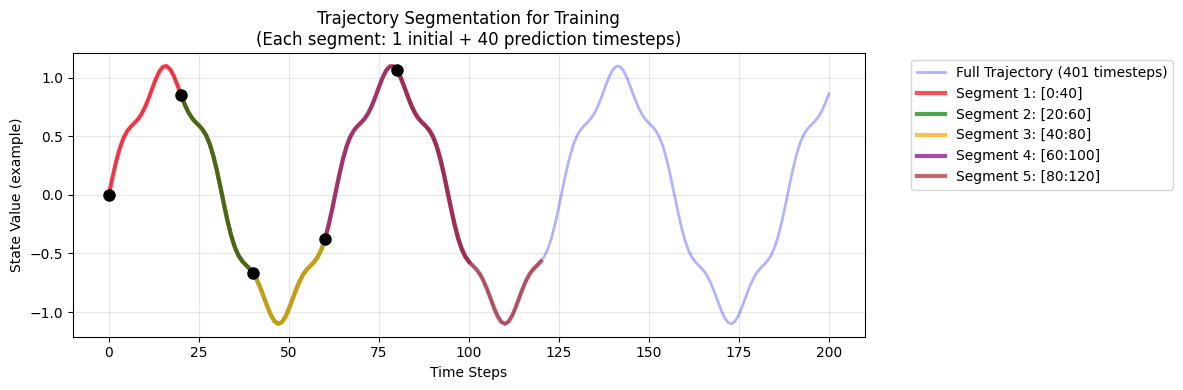


Key Points about Segmentation:
• Each segment starts with an initial condition (t[0])
• The model predicts the next 'prediction_length' timesteps
• Stride controls overlap between segments (smaller stride = more segments)
• This creates multiple training examples from each long trajectory
• Enables the model to learn dynamics from different starting points


In [51]:
# Understanding Trajectory Segmentation for Training
print("=== TRAJECTORY SEGMENTATION EXPLAINED ===")

# Let's demonstrate how trajectory segmentation works
def explain_segmentation(total_timesteps, prediction_length, stride):
    """Visualize how a trajectory is segmented for training."""
    print(f"\nTrajectory Segmentation Example:")
    print(f"  - Original trajectory length: {total_timesteps} timesteps")
    print(f"  - Prediction length: {prediction_length} timesteps")
    print(f"  - Stride (overlap): {stride} timesteps")
    
    chunk_size = prediction_length + 1  # +1 for initial condition
    segments = []
    
    for start in range(0, total_timesteps - chunk_size + 1, stride):
        end = start + chunk_size
        segments.append((start, end-1))
    
    print(f"\nGenerated segments:")
    for i, (start, end) in enumerate(segments):
        print(f"  Segment {i+1}: timesteps [{start}:{end}] -> input t[{start}], predict t[{start+1}:{end}]")
    
    print(f"\nTotal segments from one trajectory: {len(segments)}")
    return len(segments)

# Example with IRMA parameters
segments_per_traj = explain_segmentation(
    total_timesteps=401, 
    prediction_length=40, 
    stride=40
)

print(f"\nWith {irma_config['num_samples']} trajectories:")
print(f"  Total training segments: {segments_per_traj * irma_config['num_samples']}")

# Visualize the segmentation concept
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Original trajectory
trajectory_length = 201
x = np.arange(trajectory_length)
y = np.sin(x * 0.1) + 0.1 * np.sin(x * 0.5)  # Example trajectory

ax.plot(x, y, 'b-', alpha=0.3, linewidth=2, label='Full Trajectory (401 timesteps)')

# Show segments
prediction_length = 40
stride = 20
colors = ['red', 'green', 'orange', 'purple', 'brown']

for i, start in enumerate(range(0, trajectory_length - prediction_length, stride)):
    if i >= 5:  # Show only first 5 segments for clarity
        break
    end = start + prediction_length + 1
    ax.plot(x[start:end], y[start:end], colors[i], linewidth=3, alpha=0.7, 
            label=f'Segment {i+1}: [{start}:{end-1}]')
    
    # Mark initial condition
    ax.plot(x[start], y[start], 'ko', markersize=8)

ax.set_xlabel('Time Steps')
ax.set_ylabel('State Value (example)')
ax.set_title('Trajectory Segmentation for Training\n(Each segment: 1 initial + 40 prediction timesteps)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Points about Segmentation:")
print("• Each segment starts with an initial condition (t[0])")
print("• The model predicts the next 'prediction_length' timesteps")
print("• Stride controls overlap between segments (smaller stride = more segments)")
print("• This creates multiple training examples from each long trajectory")
print("• Enables the model to learn dynamics from different starting points")

In [53]:
# Example 2: Repressilator and Duffing Oscillator Configurations
print("=== Example 2: Other Dynamical Systems ===")

# Repressilator Configuration
print("\n--- Repressilator Configuration ---")
repressilator_config = {
    "dataset": "isolated_repressilator",
    "data_dir": "../data", 
    "num_combinations": 1,
    "num_samples": 50,           # Number of trajectories
    "time_steps": 201,           # Total timesteps per trajectory  
    "max_time": 250,             # Time interval
    "prediction_length": 50,     # Longer segments for oscillatory behavior
    "stride": 25,                # Half-overlap
    "normalize": "scale",
    "batch_size": 16,
    "train_size": 0.8,
    "val_size": 0.1
}

# Duffing Oscillator Configuration  
print("\n--- Duffing Oscillator Configuration ---")
duffing_config = {
    "dataset": "duffing_oscillator",
    "data_dir": "../data",
    "num_combinations": 1, 
    "num_samples": 200,          # More trajectories for chaotic system
    "time_steps": 201,           # Total timesteps per trajectory
    "max_time": 10,              # Shorter time interval
    "prediction_length": 30,     # Medium segments for chaotic dynamics
    "stride": 15,                # Half-overlap
    "normalize": "scale",
    "batch_size": 32,
    "train_size": 0.8,
    "val_size": 0.1
}

# Show parameter defaults
print("Default parameters for each system:")
temp_handler = KoopmanDataHandler(repressilator_config)
print(f"  Repressilator: {temp_handler.data_parameters}")

temp_handler = KoopmanDataHandler(duffing_config) 
print(f"  Duffing: {temp_handler.data_parameters}")

# Production-scale configurations (as used in actual experiments)
print("\n=== Production-Scale Configurations ===")
production_configs = {
    "IRMA": {
        "num_samples": 3000,
        "time_steps": 401, 
        "max_time": 800,
        "prediction_length": 40,
        "stride": 40,
        "expected_segments_per_traj": 10,
        "total_segments": 3000 * 10
    },
    "Repressilator": {
        "num_samples": 15000,
        "time_steps": 201,
        "max_time": 250, 
        "prediction_length": 200,
        "stride": 200,
        "expected_segments_per_traj": 1,   
        "total_segments": 15000 * 1
    },
    "Duffing": {
        "num_samples": 6000,
        "time_steps": 201,
        "max_time": 10,
        "prediction_length": 50,
        "stride": 50,
        "expected_segments_per_traj": 1,
        "total_segments": 6000 * 1
    }
}

for system, config in production_configs.items():
    print(f"\n{system} Production Scale:")
    print(f"  - Trajectories: {config['num_samples']:,}")
    print(f"  - Timesteps per trajectory: {config['time_steps']}")
    print(f"  - Prediction segments per trajectory: {config['expected_segments_per_traj']}")
    print(f"  - Total training segments: {config['total_segments']:,}")
    print(f"  - Each segment: {config['prediction_length']} prediction steps")
    
print("\n" + "="*60)
print("Key Advantages of Using KoopmanDataHandler:")
print("• Automatic data generation if files don't exist")
print("• Consistent preprocessing across all systems")
print("• Configurable trajectory segmentation")
print("• Built-in train/val/test splitting")
print("• Multiple normalization options")
print("• Ready-to-use PyTorch DataLoaders")
print("• Handles different data formats seamlessly")

=== Example 2: Other Dynamical Systems ===

--- Repressilator Configuration ---

--- Duffing Oscillator Configuration ---
Default parameters for each system:
  Repressilator: [1, 1000, 1, 2, 1, 5, 5]
  Duffing: [0, 1.0, -1.0, 0, 1.2]

=== Production-Scale Configurations ===

IRMA Production Scale:
  - Trajectories: 3,000
  - Timesteps per trajectory: 401
  - Prediction segments per trajectory: 10
  - Total training segments: 30,000
  - Each segment: 40 prediction steps

Repressilator Production Scale:
  - Trajectories: 15,000
  - Timesteps per trajectory: 201
  - Prediction segments per trajectory: 1
  - Total training segments: 15,000
  - Each segment: 200 prediction steps

Duffing Production Scale:
  - Trajectories: 6,000
  - Timesteps per trajectory: 201
  - Prediction segments per trajectory: 1
  - Total training segments: 6,000
  - Each segment: 50 prediction steps

Key Advantages of Using KoopmanDataHandler:
• Automatic data generation if files don't exist
• Consistent preprocess

## Summary

This notebook has demonstrated the data generation pipeline for three important dynamical systems in the BioKoopman project:

### Key Features of the Data Generation Process:

1. **Systematic Parameter Exploration**: Each system uses appropriate parameter ranges to capture diverse dynamics
2. **Multiple Initial Conditions**: Random initial conditions ensure good coverage of the state space
3. **Consistent Data Format**: All systems use the same DataFrame structure for easy processing
4. **Scalable Generation**: The pipeline can generate datasets of various sizes for different experimental needs

### System-Specific Insights:

- **Repressilator**: 6-dimensional gene regulatory oscillator with rich temporal dynamics
- **Duffing Oscillator**: 2-dimensional mechanical system with chaotic and periodic regimes
- **IRMA Model**: 5-dimensional gene network with complex regulatory interactions